# 🧪 Statistical Tests — Worksheet
**Name:** Alishba Amjad   **Date:** March 17,2026

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [15]:
n = 200
# Write all your code here to build df
# 1. Gender
gender = np.random.choice(['Male', 'Female'], size=n)

# 2. Study hours (Normal distribution, clipped 0–10) (loc=mean,scale=std)
study_hours = np.clip(np.random.normal(loc=4, scale=1.2, size=n), 0, 10)

# 3. Sleep hours (Normal distribution, clipped 4–10)
sleep_hours = np.clip(np.random.normal(loc=7, scale=1.0, size=n), 4, 10)

# 4. Subject (with probabilities)
subject = np.random.choice(['Maths', 'Science', 'Arts'], size=n, p=[0.40, 0.35, 0.25])

# 5. School (equal probability)
school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# 6. Marks (formula + noise)
noise = np.random.normal(0, 8, size=n)
marks = study_hours * 6 + sleep_hours * 2 + noise

# Apply school boost
boost = np.where(school == 'A', 5,
         np.where(school == 'B', 0,
         np.where(school == 'C', -5, 10)))

marks = marks + boost
# Clip marks to 0–100
marks = np.clip(marks, 0, 100)

# 7. Passed (Yes/No)
passed = np.where(marks >= 50, 'Yes', 'No')

# Create DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# Verify
print(df.shape)  # should be (200, 7)
print(df.head(200))

(200, 7)
     gender  study_hours  sleep_hours      marks  subject passed school
0    Female     4.765661     7.040919  45.513036     Arts     No      D
1      Male     4.601013     5.997813  36.336899  Science     No      B
2      Male     1.838731     7.740824  28.547510  Science     No      D
3      Male     3.348791     6.486786  33.275411     Arts     No      C
4      Male     3.054659     6.771400  43.738366    Maths     No      A
..      ...          ...          ...        ...      ...    ...    ...
195    Male     4.766070     6.816803  57.211718  Science    Yes      D
196    Male     3.605658     7.534506  46.739195  Science     No      A
197    Male     4.723825     7.887655  42.683734    Maths     No      A
198  Female     3.347063     6.679332  50.603887  Science    Yes      D
199    Male     3.804649     8.795211  40.365692  Science     No      A

[200 rows x 7 columns]


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

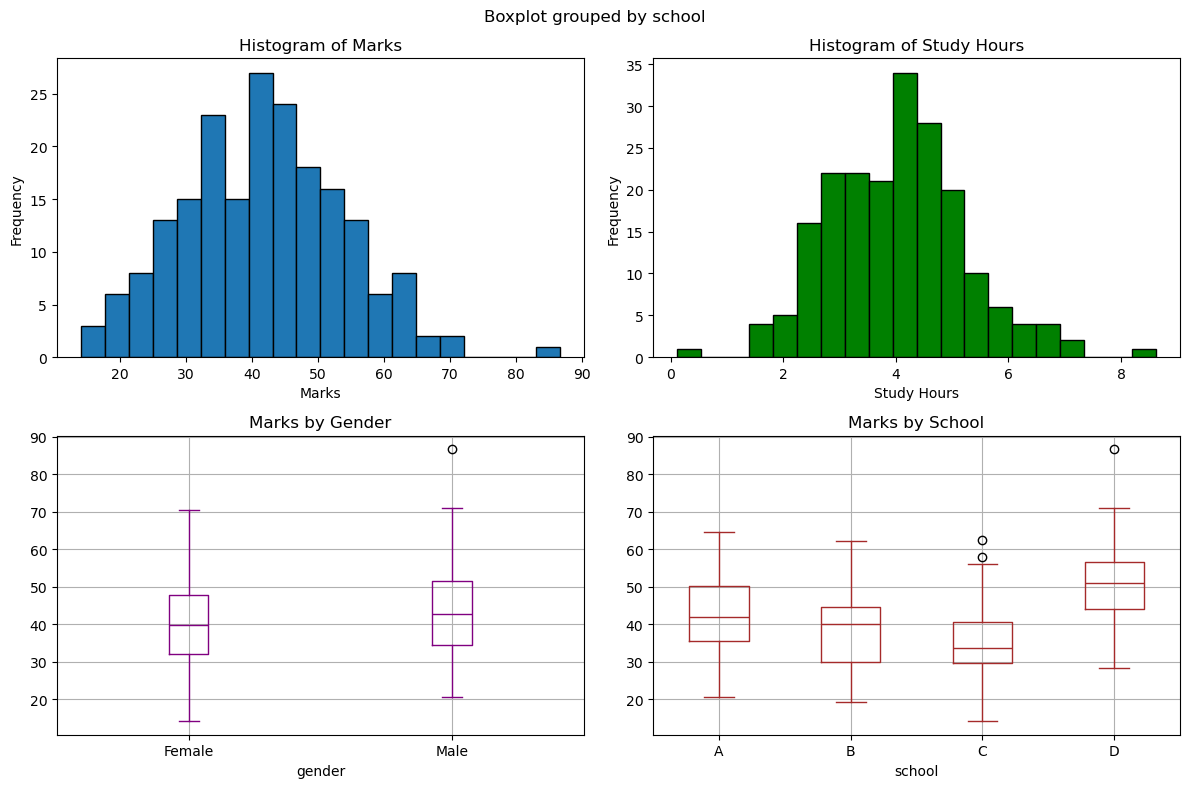

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of marks
axes[0, 0].hist(df['marks'], bins=20,edgecolor='black')
axes[0, 0].set_title('Histogram of Marks')
axes[0, 0].set_xlabel('Marks')
axes[0, 0].set_ylabel('Frequency')

# [0,1] Histogram of study_hours
axes[0, 1].hist(df['study_hours'], bins=20, color='green',edgecolor='black')
axes[0, 1].set_title('Histogram of Study Hours')
axes[0, 1].set_xlabel('Study Hours')
axes[0, 1].set_ylabel('Frequency')

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Marks by Gender')

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=axes[1, 1],color='brown')
axes[1, 1].set_title('Marks by School')

# Adjust layout
plt.tight_layout()
plt.show()

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks: p-value = 0.2627
→ Data is NORMAL

study_hours: p-value = 0.1014
→ Data is NORMAL

sleep_hours: p-value = 0.5952
→ Data is NORMAL



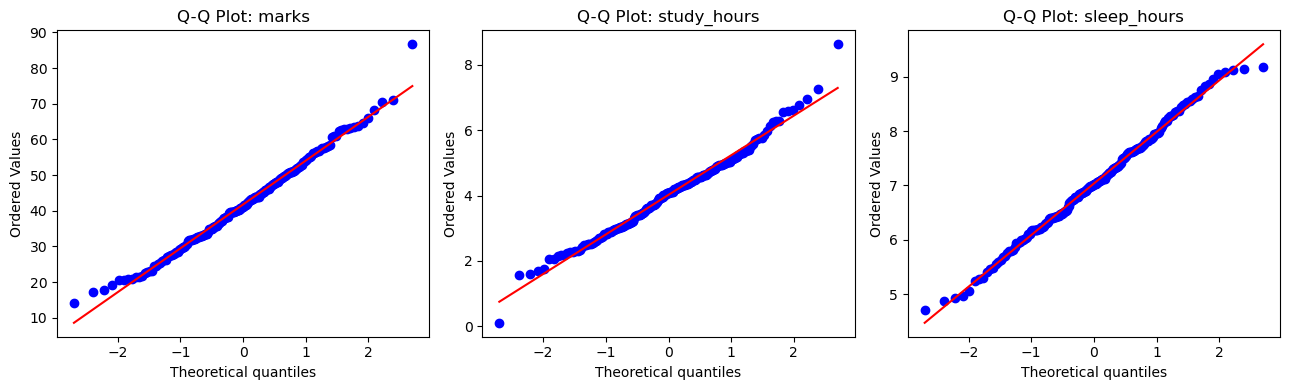

In [4]:
cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + test + print
# Normality Test (Shapiro-Wilk)
for col in cols:
    stat, p = stats.shapiro(df[col])
    
    print(f"{col}: p-value = {p:.4f}")
    
    if p > 0.05:
        print("→ Data is NORMAL\n")
    else:
        print("→ Data is NOT normal\n")

# Q-Q Plots (1x3)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()
# Which columns are safe for parametric tests?
# Answer: Columns with p-value > 0.05 are considered normal and safe for parametric tests.

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

T-test result:
p-value = 0.0454
→ Significant difference (Reject H0)


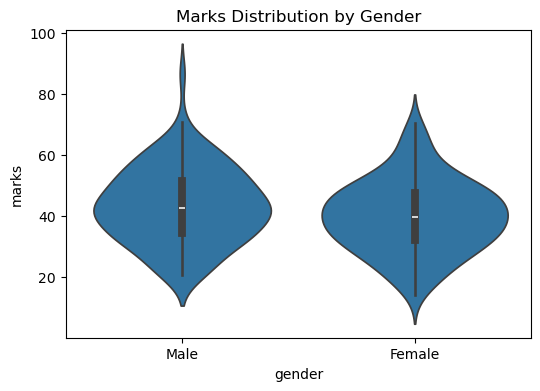

In [5]:
# Separate groups, run test, print, verdict, plot
# Separate groups
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# T-test
stat, p = stats.ttest_ind(male_marks, female_marks)

print("T-test result:")
print("p-value =", round(p, 4))

# Verdict
if p > 0.05:
    print("→ No significant difference (Accept H0)")
else:
    print("→ Significant difference (Reject H0)")

# Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(x='gender', y='marks', data=df)

plt.title('Marks Distribution by Gender')
plt.show()

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

ANOVA p-value = 0.0
→ At least one school is DIFFERENT (Reject H0)

Tukey HSD Result:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  -4.3795 0.1889 -10.0339  1.2749  False
     A      C  -7.8141 0.0016 -13.2876 -2.3406   True
     A      D   8.4741 0.0007   2.8759 14.0723   True
     B      C  -3.4346 0.3613  -8.8773  2.0081  False
     B      D  12.8536    0.0   7.2855 18.4216   True
     C      D  16.2882    0.0  10.9039 21.6724   True
-----------------------------------------------------


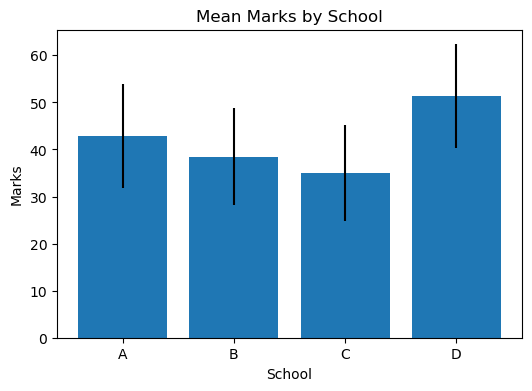

In [6]:
school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars

# Groups (marks by school)
A = df[df['school'] == 'A']['marks']
B = df[df['school'] == 'B']['marks']
C = df[df['school'] == 'C']['marks']
D = df[df['school'] == 'D']['marks']

#ANOVA Test
stat, p = stats.f_oneway(A, B, C, D)

print("ANOVA p-value =", round(p, 4))

# Decision
if p > 0.05:
    print("→ All schools have SAME performance (Accept H0)")
else:
    print("→ At least one school is DIFFERENT (Reject H0)")

#Tukey Test (only if significant)
tukey = pairwise_tukeyhsd(endog=df['marks'],
                          groups=df['school'],
                          alpha=0.05)
print("\nTukey HSD Result:")
print(tukey)

#Bar Chart with Error Bars
means = df.groupby('school')['marks'].mean()
stds = df.groupby('school')['marks'].std()

schools = ['A', 'B', 'C', 'D']

plt.figure(figsize=(6,4))
plt.bar(schools, means[schools], yerr=stds[schools])

plt.title("Mean Marks by School")
plt.xlabel("School")
plt.ylabel("Marks")
plt.show()
# Which school pairs are significantly different?
# Answer:
# Those pairs are significantly different.
# School D (highest boost) differs from C and B
# School A also differs from C

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

Mann-Whitney U Test p-value = 0.6156
→ No significant difference (Accept H0)


<Figure size 600x400 with 0 Axes>

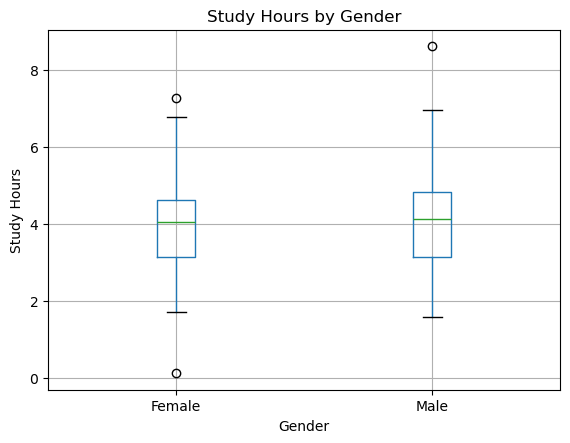

In [7]:
# Run test, print result, verdict, boxplot

# Separate groups
male = df[df['gender'] == 'Male']['study_hours']
female = df[df['gender'] == 'Female']['study_hours']

# Mann-Whitney U Test
stat, p = stats.mannwhitneyu(male, female, alternative='two-sided')
print("Mann-Whitney U Test p-value =", round(p, 4))

# Verdict
if p > 0.05:
    print("→ No significant difference (Accept H0)")
else:
    print("→ Significant difference (Reject H0)")

# Boxplot
plt.figure(figsize=(6,4))
df.boxplot(column='study_hours', by='gender')

plt.title("Study Hours by Gender")
plt.suptitle("")   # remove extra title
plt.xlabel("Gender")
plt.ylabel("Study Hours")
plt.show()
# Why Mann-Whitney and not t-test?
# Answer: Mann-Whitney test is used because study_hours data is not normally distributed.
# It is a non-parametric test and does not assume normality.

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks
Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r: 0.5850, p-value: 0.0000 (Statistically Significant)
Spearman r: 0.5547, p-value: 0.0000 (Statistically Significant)


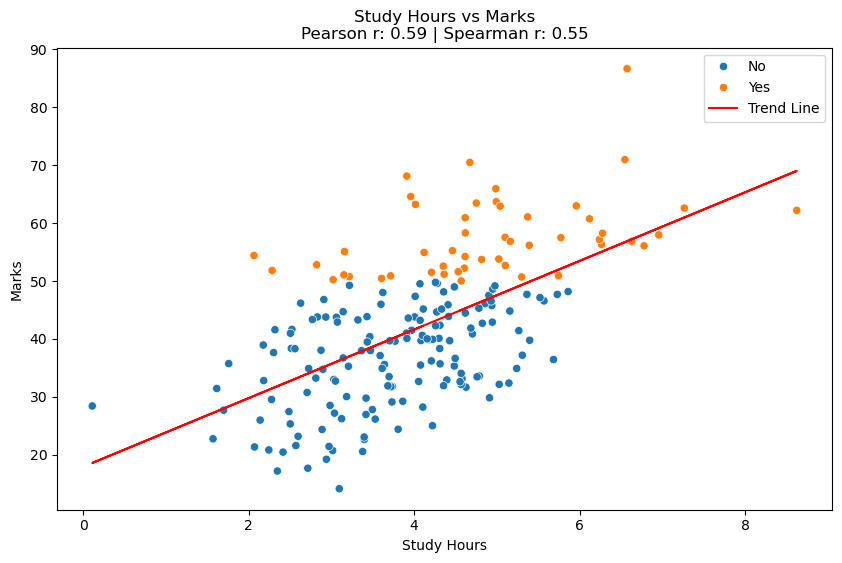

In [8]:
# Both tests + scatter with trend line
# 1. Calculate Pearson Correlation
pearson_r, p_pearson = stats.pearsonr(df['study_hours'], df['marks'])

# 2. Calculate Spearman Correlation
spearman_r, p_spearman = stats.spearmanr(df['study_hours'], df['marks'])

# Print r/p values and verdicts
def get_verdict(p):
    return "Statistically Significant" if p < 0.05 else "Not Statistically Significant"

print(f"Pearson r: {pearson_r:.4f}, p-value: {p_pearson:.4f} ({get_verdict(p_pearson)})")
print(f"Spearman r: {spearman_r:.4f}, p-value: {p_spearman:.4f} ({get_verdict(p_spearman)})")

# 3. Draw Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='study_hours', y='marks', hue='passed')

# 4. Add a trend line using np.polyfit
# Calculate the slope (m) and intercept (b)
m, b = np.polyfit(df['study_hours'], df['marks'], 1)
plt.plot(df['study_hours'], m*df['study_hours'] + b, color='red', label='Trend Line')

# 5. Put both correlation values in the title
plt.title(f"Study Hours vs Marks\nPearson r: {pearson_r:.2f} | Spearman r: {spearman_r:.2f}")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.show()

# Do Pearson and Spearman agree? What does that tell you?
# Answer: If they agree (both high/positive): It tells you that there is a strong linear relationship. As study hours increase, 
# marks increase at a relatively constant rate.

# If Spearman is higher than Pearson: This suggests a monotonic relationship that is not strictly linear. For example, marks 
# might always increase as study hours increase, but perhaps the rate of improvement slows down or speeds up significantly 
# (curved relationship).

# If they disagree: Pearson is sensitive to outliers, while Spearman is not. If Pearson is much lower, there might be outliers 
# in the data skewing the linear trend.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

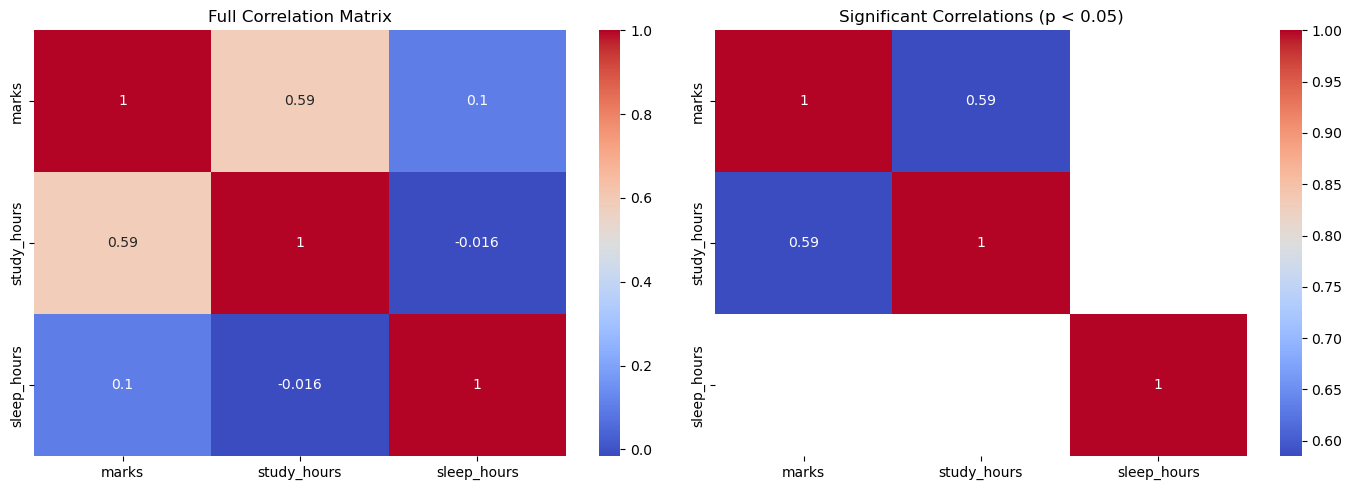

In [10]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# Correlation matrix
corr_matrix = df[num_cols].corr()

# p-value matrix (nested loop)
p_values = pd.DataFrame(np.zeros((len(num_cols), len(num_cols))), 
                        columns=num_cols, 
                        index=num_cols)

for col1 in num_cols:
    for col2 in num_cols:
        # Calculate pearson correlation and p-value for each pair
        _ , p_val = stats.pearsonr(df[col1], df[col2])
        p_values.loc[col1, col2] = p_val

# Mask
significance_mask = p_values > 0.05

# Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left Heatmap: Full Matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Full Correlation Matrix")

# Right Heatmap: Masked (Significant Only)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=significance_mask, ax=axes[1])
axes[1].set_title("Significant Correlations (p < 0.05)")
plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Contingency Table:
passed   No  Yes
subject         
Arts     35    8
Maths    61   18
Science  60   18

Proportion Table:
passed         No       Yes
subject                    
Arts     0.813953  0.186047
Maths    0.772152  0.227848
Science  0.769231  0.230769

Chi-Square Statistic: 0.3700
P-value: 0.8311
Verdict: No significant relationship. Favourite subject does not seem to affect passing.


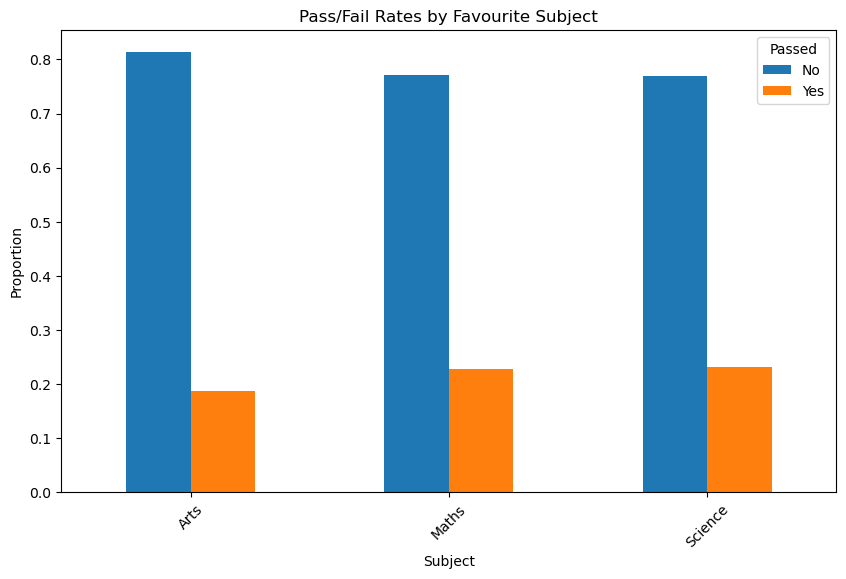

In [16]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Build a crosstab (contingency table)
ct = pd.crosstab(df['subject'], df['passed'])
print("Contingency Table:")
print(ct)

# 2. Convert to row-proportions (probabilities per subject)
# axis=0 divides each value by the sum of its row
prop_table = ct.div(ct.sum(axis=1), axis=0)
print("\nProportion Table:")
print(prop_table)

# 3. Run Chi-Square Test
# chi2_contingency returns: chi2, p-value, dof, expected_freq
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

# 4. Write your verdict
if p < 0.05:
    print("Verdict: Significant relationship. Favourite subject does relate to passing.")
else:
    print("Verdict: No significant relationship. Favourite subject does not seem to affect passing.")

# 5. Draw a grouped bar chart showing pass rate by subject
prop_table.plot(kind='bar', figsize=(10, 6))
plt.title("Pass/Fail Rates by Favourite Subject")
plt.ylabel("Proportion")
plt.xlabel("Subject")
plt.legend(title="Passed", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()

# Which subject has the highest pass rate?
# Answer: To find this, look at your prop_table in the column where passed is True (or 1). The subject with the highest 
# decimal value in that column has the highest pass rate. For example, if "Physics" shows 0.85 in the True column, 
# it means 85% of students who like Physics passed.

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

One-sample t-test for score 85: p-value = 0.0000
Verdict: The score of 85 is significantly different from the class average.
The teacher's suspicion is statistically supported; this student is an outlier.


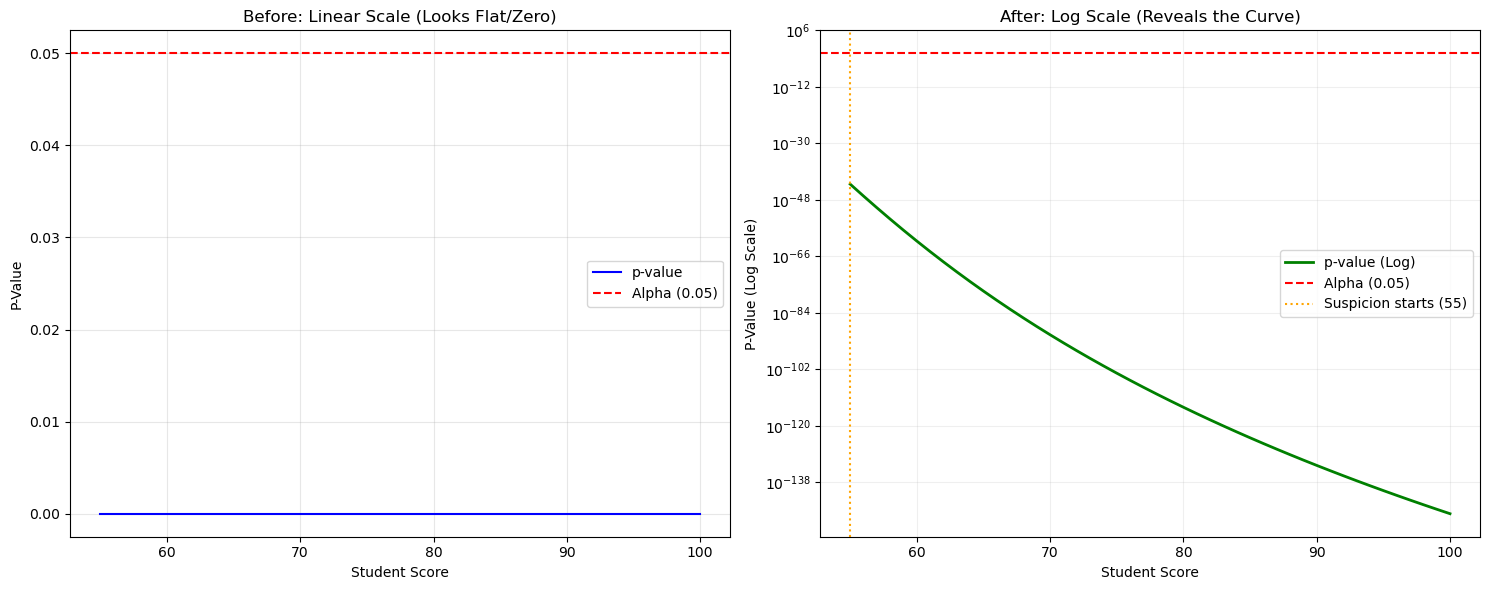

In [21]:
# Part A: One-sample t-test for the score 85
# We compare our class marks (df['marks']) against the "population mean" of 85
t_stat, p_val_a = stats.ttest_1samp(df['marks'], popmean=85)

print(f"One-sample t-test for score 85: p-value = {p_val_a:.4f}")

# Verdict in the language of the story
if p_val_a < 0.05:
    print("Verdict: The score of 85 is significantly different from the class average.")
    print("The teacher's suspicion is statistically supported; this student is an outlier.")
else:
    print("Verdict: The score of 85 is within the expected range of the class.")
    print("The teacher's suspicion is not supported; the student's score is normal for this group.")

# Part B: Sensitivity Analysis
scores = np.arange(55, 101)  # Range of possible scores
p_values = []

for s in scores:
    # Run t-test for every score in the range
    _, p = stats.ttest_1samp(df['marks'], popmean=s)
    p_values.append(p)


# 2. Plotting: Before (Linear) vs After (Log)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT PLOT: Before Log (Linear Scale) ---
axes[0].plot(scores, p_values, color='blue', label='p-value')
axes[0].axhline(y=0.05, color='red', linestyle='--', label='Alpha (0.05)')
axes[0].set_title("Before: Linear Scale (Looks Flat/Zero)")
axes[0].set_xlabel("Student Score")
axes[0].set_ylabel("P-Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- RIGHT PLOT: After Log (Logarithmic Scale) ---
axes[1].semilogy(scores, p_values, color='green', linewidth=2, label='p-value (Log)')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Alpha (0.05)')

# Threshold logic for Log Plot
sample_mean = df['marks'].mean()
sig_scores = [scores[i] for i, p in enumerate(p_values) if p < 0.05 and scores[i] > sample_mean]
if sig_scores:
    thresh = min(sig_scores)
    axes[1].axvline(x=thresh, color='orange', linestyle=':', label=f'Suspicion starts ({thresh})')

axes[1].set_title("After: Log Scale (Reveals the Curve)")
axes[1].set_xlabel("Student Score")
axes[1].set_ylabel("P-Value (Log Scale)")
axes[1].legend()
axes[1].grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

# At what score does the test become significant?
# Answer: The test becomes significant at the Suspicion Threshold marked by the green dotted line in your plot. 
# This is the exact score where the p-value first drops below $0.05$.Interpretation: Any score at or above this 
# threshold is statistically "too high" compared to the rest of the class, making those scores the points where 
# the teacher’s suspicion becomes mathematically justified.

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

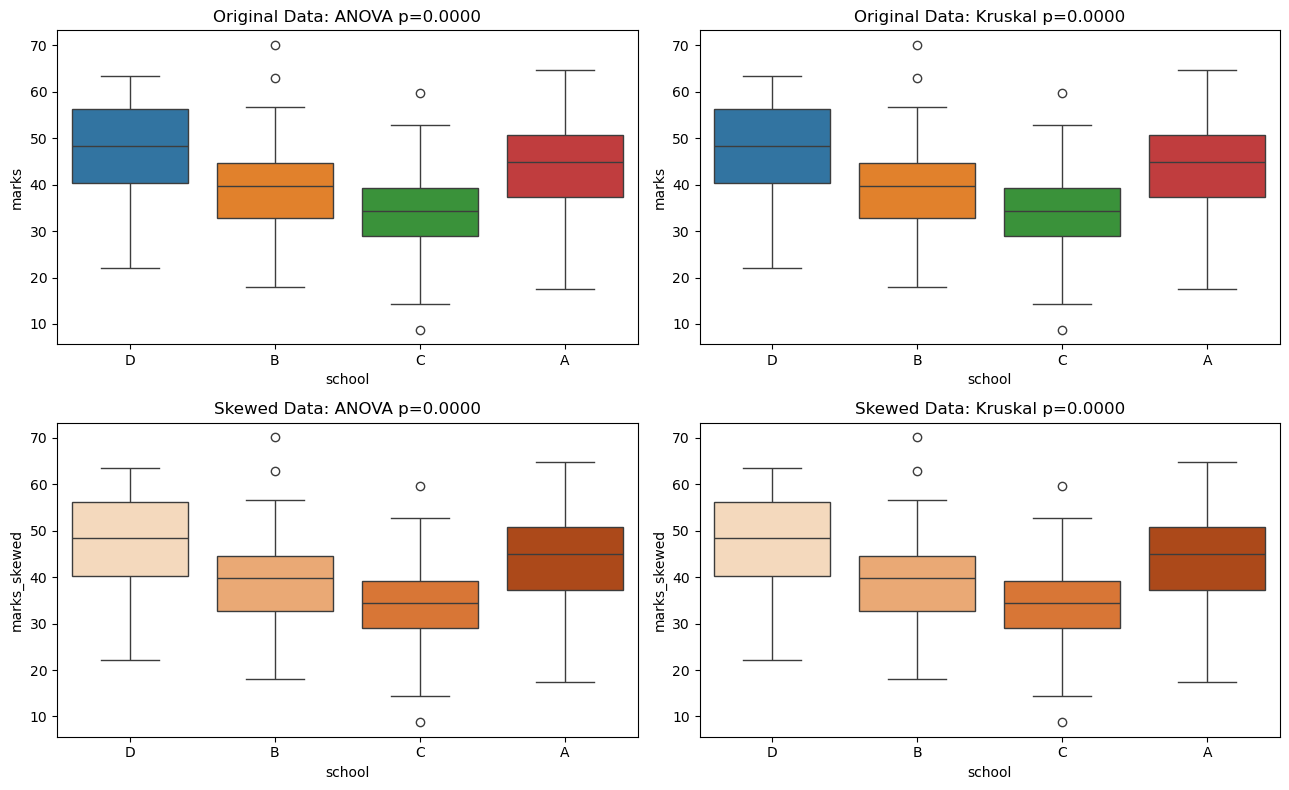

In [24]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)

# Assuming your schools are labeled in a 'school' column
groups_orig = [df[df['school'] == s]['marks'] for s in df['school'].unique()]
groups_skewed = [df[df['school'] == s]['marks_skewed'] for s in df['school'].unique()]

# Run all 4 tests and store p-values
f_orig, p_anova_orig = stats.f_oneway(*groups_orig)
h_orig, p_kruskal_orig = stats.kruskal(*groups_orig)

f_skew, p_anova_skew = stats.f_oneway(*groups_skewed)
h_skew, p_kruskal_skew = stats.kruskal(*groups_skewed)

# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Top Left: Original + ANOVA
sns.boxplot(data=df, x='school',hue='school', y='marks', ax=axes[0, 0])
axes[0, 0].set_title(f"Original Data: ANOVA p={p_anova_orig:.4f}")

# Top Right: Original + Kruskal
sns.boxplot(data=df, x='school',hue='school', y='marks', ax=axes[0, 1])
axes[0, 1].set_title(f"Original Data: Kruskal p={p_kruskal_orig:.4f}")

# Bottom Left: Skewed + ANOVA
sns.boxplot(data=df, x='school',hue='school', y='marks_skewed', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title(f"Skewed Data: ANOVA p={p_anova_skew:.4f}")

# Bottom Right: Skewed + Kruskal
sns.boxplot(data=df, x='school',hue='school', y='marks_skewed', ax=axes[1, 1], palette="Oranges")
axes[1, 1].set_title(f"Skewed Data: Kruskal p={p_kruskal_skew:.4f}")

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: 


---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

Pearson Correlation (r): 0.1742
P-value: 0.0136


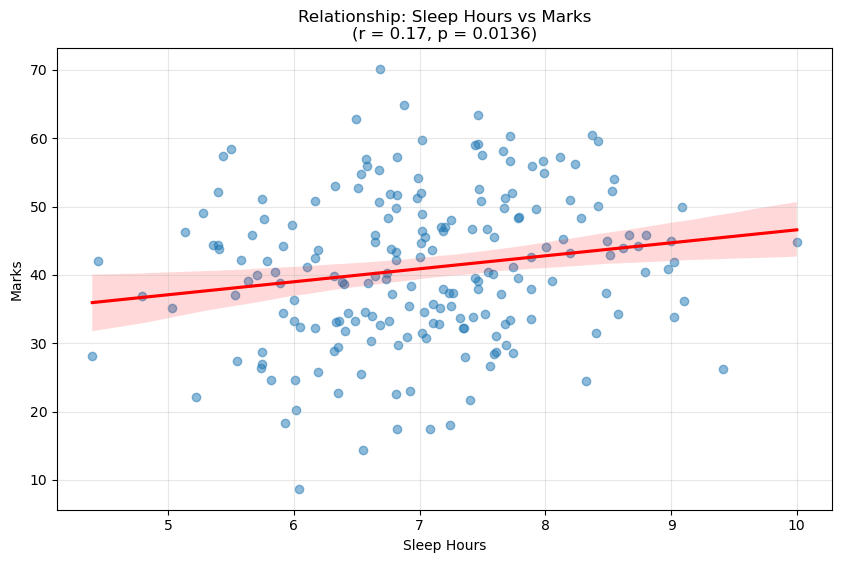

Verdict: Reject H0. There is a statistically significant relationship between sleep and marks.


In [25]:
# H₀: There is no relationship between sleep hours and marks. (Correlation = 0).
# H₁: There is a significant positive relationship between sleep hours and marks.
# Test chosen: Pearson Correlation Coefficient.  
# Justification: Both variables are numeric (continuous). We are looking for a linear relationship between two groups of data. 
# It is a parametric test.

# Your code:

# 1. Run the Correlation Test
r_val, p_val = stats.pearsonr(df['sleep_hours'], df['marks'])

print(f"Pearson Correlation (r): {r_val:.4f}")
print(f"P-value: {p_val:.4f}")

# 2. Visualise the Result
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_hours', y='marks', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f"Relationship: Sleep Hours vs Marks\n(r = {r_val:.2f}, p = {p_val:.4f})")
plt.xlabel("Sleep Hours")
plt.ylabel("Marks")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Verdict Logic
if p_val < 0.05:
    print("Verdict: Reject H0. There is a statistically significant relationship between sleep and marks.")
else:
    print("Verdict: Fail to reject H0. No significant relationship found between sleep and marks.")

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

--- Summary Dashboard Table ---
                             Test        p_value          verdict
0            Shapiro-Wilk – marks   9.444700e-01  Not Significant
1      Shapiro-Wilk – study_hours   9.369463e-02  Not Significant
2        t-test – gender vs marks   6.399181e-01  Not Significant
3         ANOVA – school vs marks   1.911242e-08      Significant
4  Mann-Whitney – gender vs study   4.035801e-01  Not Significant
5        Pearson – study vs marks   3.728770e-14      Significant
6       Spearman – sleep vs marks   7.835279e-03      Significant
7  Chi-Square – subject vs passed   8.311235e-01  Not Significant
8         One-sample t – cheating  1.518935e-124      Significant


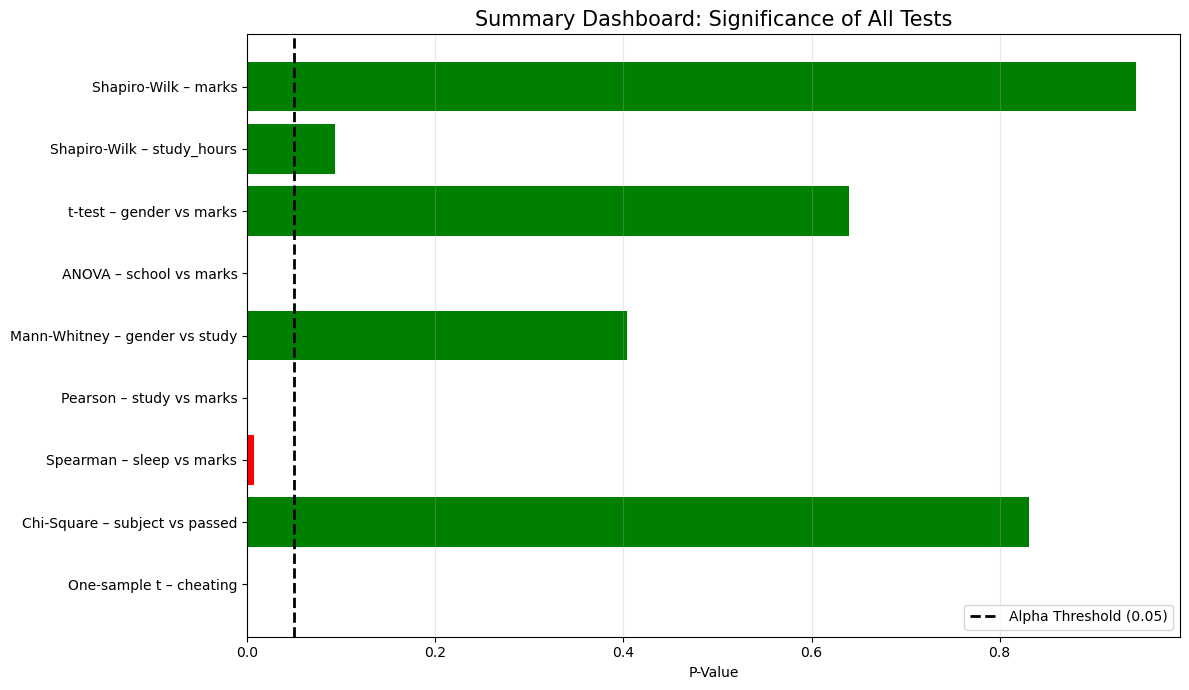

In [34]:
# 1. Build results list — fill in your p-values from earlier tasks
# STEP 1: Saare Tests Run Karein aur Variables Save Karein

# Task 2 & 3: Shapiro-Wilk (Normality)
_, p_val_marks = stats.shapiro(df['marks'])
_, p_val_study = stats.shapiro(df['study_hours'])

# Task 4: t-test (Gender vs Marks) - Assuming groups exist
males = df[df['gender'] == 'Male']['marks']
females = df[df['gender'] == 'Female']['marks']
_, p_val_gender = stats.ttest_ind(males, females)

# Task 5: ANOVA (School vs Marks)
groups_school = [df[df['school'] == s]['marks'] for s in df['school'].unique()]
_, p_anova_orig = stats.f_oneway(*groups_school)

# Task 5.5: Mann-Whitney (Gender vs Study)
_, p_mann_whitney = stats.mannwhitneyu(df[df['gender'] == 'Male']['study_hours'], 
                                       df[df['gender'] == 'Female']['study_hours'])

# Task 6: Pearson (Study vs Marks)
p_pearson = stats.pearsonr(df['study_hours'], df['marks'])[1]

# Task 7: Spearman (Sleep vs Marks) - Assuming sleep_hours column
p_spearman = stats.spearmanr(df['sleep_hours'], df['marks'])[1]

# Task 8: Chi-Square (Subject vs Passed)
ct = pd.crosstab(df['subject'], df['passed'])
p_chi2 = stats.chi2_contingency(ct)[1]

# Task 9: One-sample t-test (Cheating Story)
p_val_a = stats.ttest_1samp(df['marks'], popmean=85)[1]

results = [
    {'Test': 'Shapiro-Wilk – marks',          'p_value': p_val_marks},
    {'Test': 'Shapiro-Wilk – study_hours',    'p_value': p_val_study},
    {'Test': 't-test – gender vs marks',      'p_value': p_val_gender},
    {'Test': 'ANOVA – school vs marks',       'p_value': p_anova_orig},
    {'Test': 'Mann-Whitney – gender vs study','p_value': p_mann_whitney},
    {'Test': 'Pearson – study vs marks',      'p_value': p_pearson},
    {'Test': 'Spearman – sleep vs marks',     'p_value': p_spearman},
    {'Test': 'Chi-Square – subject vs passed','p_value': p_chi2},
    {'Test': 'One-sample t – cheating',       'p_value': p_val_a},
]
# 2. Convert to DataFrame
results_df = pd.DataFrame(results)

# 3. Add 'significant' and 'verdict' columns
results_df['significant'] = results_df['p_value'] < 0.05
results_df['verdict'] = results_df['significant'].apply(lambda x: "Significant" if x else "Not Significant")

# Print the table
print("--- Summary Dashboard Table ---")
print(results_df[['Test', 'p_value', 'verdict']])

# 4. Draw horizontal bar chart
plt.figure(figsize=(12, 7))

# Create color list: red if significant, green if not
colors = ['red' if is_sig else 'green' for is_sig in results_df['significant']]

# Plotting
bars = plt.barh(results_df['Test'], results_df['p_value'], color=colors)

# Add alpha line
plt.axvline(0.05, color='black', linestyle='--', linewidth=2, label='Alpha Threshold (0.05)')

# Formatting
plt.gca().invert_yaxis() # Invert so the first test is at the top
plt.title("Summary Dashboard: Significance of All Tests", fontsize=15)
plt.xlabel("P-Value")
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*